# CLIP-ReID ViT-B/16 · вариант 1: перенос автомобильных весов

Отдельный development-эксперимент. **Run All запускает 60 prompt-эпох + 60 image-эпох и чистый OSNet-контроль**, затем создаёт RESULTS.md. Для одной технической проверки выставь `RUN_TRAINING = False`.

Никаких raw внешних датасетов, organiser test, camera/view-входов, HPO или автоматической замены MVP. Маски проверяем в другом notebook. Inner train/validation: 741/184 identity при текущих данных. Подробности — README.md и SOURCES.md.

## 1. Окружение

Выбери kernel из `.venv` репозитория. Зависимости уже есть в `requirements-train.txt`; notebook не устанавливает их поверх глобального Python. Не запускай два экземпляра в одной папке.

In [1]:
from pathlib import Path
import os, sys, json
candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "Car-classification-MSK"]
ROOT = next((p for p in candidates if (p / "backend/core.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Открой notebook внутри Car-classification-MSK")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repository:", ROOT)


Repository: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK


In [2]:
import gc
import torch
from torch.utils.data import DataLoader
from dataclasses import asdict
from IPython.display import display, Markdown
from training.pipeline import ensure_splits, select_device, set_seed
from training.clip_source import download_checkpoint, CHECKPOINT_SHA256
from training.clip_reid import load_pretrained, ClipDataset, technical_smoke, release_device
from training.clip_export import export_smoke
from training.clip_experiment import (ClipConfig, prepare_protocol, training_rows, public_baselines,
    run_prompt_stage, run_image_stage, run_clean_osnet_control, write_results)
from training.stage6 import StepPKBatchSampler, write_json

VARIANT = ROOT / "CLIP-ReID-ViT-B-16/variant_01_vehicle_transfer"
WEIGHTS, RESULTS = VARIANT / "weights", VARIANT / "results"
SOURCE = WEIGHTS / "VeRi_clipreid_ViT-B-16_60.pth"
RUN_TRAINING = True
RUN_OSNET_CONTROL = True
RUN_EXPORT_SMOKE = True
ALLOW_CPU_TRAINING = False
config = ClipConfig()  # Новый seed/рецепт — новая папка VARIANT, не удаляй прошлые JSON.
config.validate()
device = select_device()
print("torch:", torch.__version__, "| device:", device, "| config:", asdict(config))
if RUN_TRAINING and device.type == "cpu" and not ALLOW_CPU_TRAINING:
    raise RuntimeError("GPU не обнаружен. Проверь MPS/kernel; медленное CPU-обучение не включаем молча.")


torch: 2.14.0 | device: mps | config: {'seed': 20260915, 'prompt_epochs': 60, 'image_epochs': 60, 'prompt_batch': 64, 'identities_per_batch': 8, 'images_per_identity': 4, 'prefer_cross_camera': True, 'prompt_lr': 0.00035, 'image_lr': 5e-06, 'weight_decay': 0.0001, 'eval_batch': 16}


## 2. Исходные веса и чистый протокол

Первый download — около 482 МиБ, дальше используется локальный файл. Загрузка проверяет фиксированный SHA-256; ошибочный/неполный checkpoint не подменяется случайными весами. Все изображения проверяются по хешам на утечку между identity/frame-disjoint частями.

In [3]:
if not SOURCE.exists():
    download_checkpoint(SOURCE)
rows, split = ensure_splits()
protocol = prepare_protocol(rows, split, RESULTS)
selected = training_rows(rows, protocol)
set_seed(config.seed)
model = load_pretrained(SOURCE, classes=len(protocol["inner"]["train"]), device=device)
print("Initializer SHA-256:", CHECKPOINT_SHA256)
print("Inner identities:", {k: len(v) for k, v in protocol["inner"].items()})
print("Train crops:", len(selected), "| P×K:", config.batch_size)


Initializer SHA-256: 71f6f2723be4d563f1df201133daa53f57bee2a67266486559d5ce453a60f805
Inner identities: {'train': 741, 'validation': 184}
Train crops: 4605 | P×K: 32


## 3. Проверка MPS, памяти и экспорта

По одному Adam-шагу обоих этапов, затем все веса и BN-буферы восстанавливаются. Это **не обучение кандидата и не официальный GPU benchmark**. В prompt-smoke кешированные признаки повторяются до нужного batch size; метрики качества на них не считаются. ONNX проверяется на batch=1 и 2 и не попадает в MVP.

In [4]:
smoke_loader = DataLoader(ClipDataset(selected), batch_sampler=StepPKBatchSampler(selected, config, 1))
smoke_images, smoke_labels, _ = next(iter(smoke_loader))
smoke = technical_smoke(model, smoke_images, smoke_labels, device, config.prompt_batch)
write_json(RESULTS / "technical_smoke.json", smoke)
print(json.dumps(smoke, indent=2))
if RUN_EXPORT_SMOKE:
    exported = export_smoke(model, smoke_images, RESULTS / "cache/source_image_encoder.onnx")
    write_json(RESULTS / "export_smoke.json", exported)
    print("ONNX:", exported)
del smoke_loader, smoke_images, smoke_labels
release_device(device)


{
  "device": "mps",
  "dtype": "float32",
  "batch_size": 32,
  "prompt_batch": 64,
  "adam_steps_checked": true,
  "stage1_loss": 8.74543285369873,
  "stage2_loss": 10.78928279876709,
  "forward_backward_seconds": 6.652893165999558,
  "parameter_count": 126838528,
  "image_weights_bytes": 348769296,
  "not_official_performance_benchmark": true,
  "mps_current_bytes": 1624305920,
  "mps_driver_bytes": 10284449792,
  "mps_recommended_bytes": 17179885568
}
ONNX: {'sha256': '6551b3ce998fa7d9efad987ddfde9bcd12967dd9e125dc4a15bbc6ec5eedc182', 'bytes': 345304607, 'batches_checked': [1, 2], 'embedding_dimension': 1280, 'max_absolute_error': 4.4330954551696777e-07, 'minimum_cosine': 1.000000238418579, 'image_only': True, 'mvp_changed': False, 'exporter': 'torch.onnx legacy dynamo=False, opset 17 (pinned torch environment)'}


## 4. Исходные checkpoints на одном inner holdout

Сравниваем CLIP-ReID VeRi и **stock** OSNet. Активная дообученная OSNet здесь запрещена как контроль: она уже видела inner-validation ID. Текущий baseline CLIP ≈37,53%, stock OSNet ≈65,21% mAP@10 — прирост от переноса ещё нужно доказать. Пороги отказа и реранкинг пока не настраиваем.

In [5]:
baselines = public_baselines(model, rows, protocol, device, RESULTS, batch_size=config.eval_batch)
print(json.dumps(baselines, ensure_ascii=False, indent=2))


{
  "signature": {
    "protocol": "47ae5c0c79d5cedc906a07bd06258eaa2ed8e298ab40acda449e52f5a80fa5a7",
    "clip_sha256": "71f6f2723be4d563f1df201133daa53f57bee2a67266486559d5ce453a60f805",
    "osnet_sha256": "4aaad3e5db648618b0df3d2ff21c61323985ff9e50194c3d2edd4fb87c92d91f",
    "preprocess": "exif-rgb-exact-bbox-bilinear256-mean0.5-std0.5-beforeBN-concat1280-l2-v1",
    "adapter_sha256": "d15541c88d26657183b8acdc101d8db31c945b97e07ad5d01c8a72298f296ef3"
  },
  "clip_vehicle_pretrained": {
    "mAP_at_10": 0.37525172124783396,
    "Rank_1": 0.41496598639455784,
    "Rank_5": 0.6122448979591837,
    "full_mAP": 0.4084473680155955,
    "mINP": 0.3131690921459996,
    "known_queries": 147,
    "unknown_queries": 37
  },
  "osnet_stock": {
    "mAP_at_10": 0.6521145767452862,
    "Rank_1": 0.6666666666666666,
    "Rank_5": 0.8231292517006803,
    "full_mAP": 0.6758722457086503,
    "mINP": 0.6086549252450054,
    "known_queries": 147,
    "unknown_queries": 37
  },
  "active_osnet_exclud

## 5. Этап 1 — обучаемые prompts для наших train-ID

Image/text encoders заморожены; признаки train-кропов кешируются один раз. Учим только четыре вектора контекста на identity, 60 эпох Adam + warmup/cosine. Старые VeRi ID-контексты и классификаторы сброшены, поскольку это другие автомобили. Пишется `prompt_last.pt` с optimizer/history.

In [6]:
if RUN_TRAINING:
    prompt_history = run_prompt_stage(model, selected, device, config, protocol, WEIGHTS, RESULTS)
else:
    print("Только preflight: prompt training пропущен.")
release_device(device)  # Освободить кеш MPS перед сменой этапа.


CLIP embeddings:   0%|          | 0/288 [00:00<?, ?it/s]

Prompt 1/60:   0%|          | 0/72 [00:00<?, ?it/s]

1/2: prompts | эпоха 1/60, осталось 59 | эпоха: 00:00:19 | прошло: 00:00:19 | ETA этапа: 00:18:56


Prompt 2/60:   0%|          | 0/72 [00:00<?, ?it/s]

1/2: prompts | эпоха 2/60, осталось 58 | эпоха: 00:00:19 | прошло: 00:00:39 | ETA этапа: 00:18:38


...

1/2: prompts | эпоха 58/60, осталось 2 | эпоха: 00:00:19 | прошло: 00:18:33 | ETA этапа: 00:00:38


Prompt 59/60:   0%|          | 0/72 [00:00<?, ?it/s]

1/2: prompts | эпоха 59/60, осталось 1 | эпоха: 00:00:19 | прошло: 00:18:52 | ETA этапа: 00:00:19


Prompt 60/60:   0%|          | 0/72 [00:00<?, ?it/s]

1/2: prompts | эпоха 60/60, осталось 0 | эпоха: 00:00:19 | прошло: 00:19:11 | ETA этапа: 00:00:00


## 6. Этап 2 — visual encoder

Prompts/text encoder фиксированы. Loss: 0.25 × две ID CE + три raw-Euclidean triplet + image-to-text CE. Batch 8×4, encoder LR 5e−6, bias LR ×2; warmup 10 эпох, снижение на 30/50. На каждой эпохе — официальный raw inner mAP@10.

60 эпох — один фиксированный рецепт, не Grid Search. Лучшая эпоха может быть **0**, если исходные веса лучше всех дообученных. Сохраняются last, best и эпохи 10/30/50/60. Время эпохи и ETA относятся к текущему этапу; время записи больших checkpoint не включено.

In [7]:
if RUN_TRAINING:
    summary = run_image_stage(model, rows, selected, device, config, protocol, WEIGHTS, RESULTS)
    print(json.dumps(summary, ensure_ascii=False, indent=2))
else:
    print("Только preflight: image training пропущен.")
del model
release_device(device)


CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

Image 1/60:   0%|          | 0/144 [00:00<?, ?it/s]

CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

2/2: image encoder | эпоха 1/60, осталось 59 | эпоха: 00:04:13 | прошло: 00:04:13 | ETA этапа: 04:08:40
inner raw mAP@10: 0.5088; best 0.5088, epoch 1


Image 2/60:   0%|          | 0/144 [00:00<?, ?it/s]

...

CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

2/2: image encoder | эпоха 59/60, осталось 1 | эпоха: 00:04:11 | прошло: 04:06:34 | ETA этапа: 00:04:11
inner raw mAP@10: 0.7137; best 0.7182, epoch 53


Image 60/60:   0%|          | 0/144 [00:00<?, ?it/s]

CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

2/2: image encoder | эпоха 60/60, осталось 0 | эпоха: 00:04:11 | прошло: 04:10:46 | ETA этапа: 00:00:00
inner raw mAP@10: 0.7129; best 0.7182, epoch 53
{
  "signature": {
    "protocol": "47ae5c0c79d5cedc906a07bd06258eaa2ed8e298ab40acda449e52f5a80fa5a7",
    "config": {
      "seed": 20260915,
      "prompt_epochs": 60,
      "image_epochs": 60,
      "prompt_batch": 64,
      "identities_per_batch": 8,
      "images_per_identity": 4,
      "prefer_cross_camera": true,
      "prompt_lr": 0.00035,
      "image_lr": 5e-06,
      "weight_decay": 0.0001,
      "eval_batch": 16
    },
    "code": {
      "training/clip_reid.py": "d15541c88d26657183b8acdc101d8db31c945b97e07ad5d01c8a72298f296ef3",
      "training/clip_experiment.py": "0c0be24c12cb56ba9e9cfd317984dfe177840b7c63a93a9aed67a71fffc98a82",
      "training/vendor/clip_reid/model.py": "6cd4621f8fb7d20cf80a3362f939ceb6c88d7cbf11b10d841da4a7d539dc65a2",
      "backend/scoring.py": "3b183baca71086621124777369d7ae12e24e6b0412c58203dc513d

## 7. Чистый OSNet-контроль

Отдельный запуск от stock-весов, **только inner train**, на том же holdout. Avg/BNNeck/SupCon, P=16,K=2, до 4000 шагов с early stopping. Это сравнение двух рабочих рецептов, не эксперимент с равным compute-бюджетом и не загрузка активных обученных весов.

In [8]:
if RUN_TRAINING and RUN_OSNET_CONTROL:
    control = run_clean_osnet_control(rows, protocol, device, WEIGHTS, RESULTS)
    print(json.dumps(control, ensure_ascii=False, indent=2))
else:
    print("Чистый обученный OSNet-контроль пропущен; без него сравнение обучения неполное.")


steps 1–200:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 1/20 | осталось эпох: 19 | шаги 200/4000, осталось 3800 | эпоха: 00:02:40 | прошло: 00:02:40 | ETA ≤ 00:50:32 | предъявлений: 6400, условных проходов: 1.39 | inner mAP@10: 0.7160


steps 201–400:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 2/20 | осталось эпох: 18 | шаги 400/4000, осталось 3600 | эпоха: 00:02:39 | прошло: 00:05:19 | ETA ≤ 00:47:51 | предъявлений: 12800, условных проходов: 2.78 | inner mAP@10: 0.7635


steps 401–600:   0%|          | 0/200 [00:00<?, ?it/s]

...

Эпоха 14/20 | осталось эпох: 6 | шаги 2800/4000, осталось 1200 | эпоха: 00:02:43 | прошло: 00:37:41 | ETA ≤ 00:16:09 | предъявлений: 89600, условных проходов: 19.46 | inner mAP@10: 0.7606


steps 2801–3000:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 15/20 | осталось эпох: 5 | шаги 3000/4000, осталось 1000 | эпоха: 00:02:43 | прошло: 00:40:24 | ETA ≤ 00:13:28 | предъявлений: 96000, условных проходов: 20.85 | inner mAP@10: 0.7595


steps 3001–3200:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 16/20 | осталось эпох: 4 | шаги 3200/4000, осталось 800 | эпоха: 00:02:42 | прошло: 00:43:06 | ETA ≤ 00:10:47 | предъявлений: 102400, условных проходов: 22.24 | inner mAP@10: 0.7607
{
  "config": {
    "epochs": 20,
    "identities_per_batch": 16,
    "images_per_identity": 2,
    "encoder_lr": 0.0001,
    "head_lr_multiplier": 10.0,
    "weight_decay": 0.0005,
    "warmup_epochs": 2,
    "min_lr_ratio": 0.02,
    "metric_loss": "supcon",
    "metric_weight": 1.0,
    "triplet_margin": 0.5,
    "supcon_temperature": 0.1,
    "consistency_weight": 0.1,
    "label_smoothing": 0.1,
    "use_bnneck": true,
    "prefer_cross_camera": true,
    "num_workers": 0,
    "seed": 20260915,
    "pooling": "avg",
    "resize_mode": "square",
    "use_mixstyle": false,
    "mixstyle_probability": 0.5,
    "mixstyle_alpha": 0.1,
    "hard_negative_sampling": false,
    "loss_weight_schedule": "constant",
    "metric_warmup_epochs": 4,
    "circle_margin": 0.25,
    "circle_gamma": 64.0
  },
  "b

## 8. Итог и графики

Отчёт строится по сохранённым данным. Следующие seed, outer calibration/validation, reranking и перенос в MVP — отдельное решение после анализа этого результата.

# CLIP-ReID: результаты development

Все значения ниже — raw mAP@10 на одном inner split. Outer/test не оценивались.

- Исходный CLIP-ReID VeRi: 37.5252%.
- Stock OSNet: 65.2115%.
- CLIP-ReID после отбора: 71.8209%, эпоха 53.
- Выполнено image-эпох: 60.
- Чистый inner-trained OSNet: 77.8715%; инициализация 65.2115%.

Эпоха 0 означает, что дообучение не улучшило исходные vehicle-веса.
Это выбор на validation, а не независимое подтверждение прироста. Следующее решение —
после анализа ошибок, затем дополнительные seed/калибровка/outer при перспективном результате.
Порог отказа, reranking и MVP этим экспериментом не изменены.


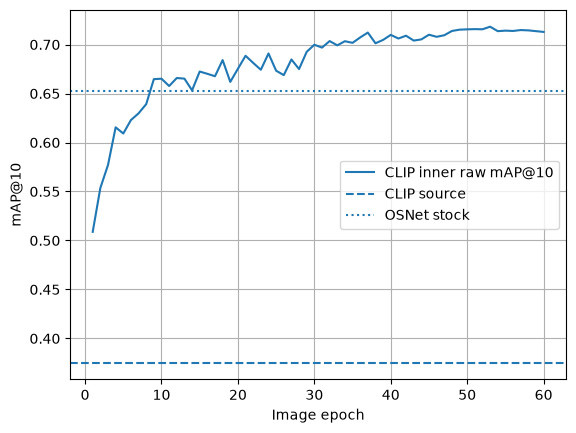

In [9]:
if (RESULTS / "training_summary.json").exists():
    write_results(RESULTS)
    display(Markdown((RESULTS / "RESULTS.md").read_text()))
    import matplotlib.pyplot as plt
    history = json.loads((RESULTS / "image_history.json").read_text())
    plt.plot([r["epoch"] for r in history], [r["validation"]["mAP_at_10"] for r in history], label="CLIP inner raw mAP@10")
    plt.axhline(baselines["clip_vehicle_pretrained"]["mAP_at_10"], label="CLIP source", linestyle="--")
    plt.axhline(baselines["osnet_stock"]["mAP_at_10"], label="OSNet stock", linestyle=":")
    plt.xlabel("Image epoch"); plt.ylabel("mAP@10"); plt.legend(); plt.grid(); plt.show()
else:
    print("Полное обучение ещё не выполнялось. Есть только технические проверки и baseline.")


## Если выполнение прервалось

Restart Kernel → Run All с прежним VARIANT/config. Незавершённая эпоха повторится с последней атомарной границы. JSON восстанавливаются из checkpoint; вручную удалять их не нужно. Для совершенно нового эксперимента задай другую папку VARIANT. При изменении данных, config, версии torch или исходников resume остановится с понятной ошибкой. Не отключай проверку подписи.